# Import libraries

In [9]:
import os
from re import search
from dfply import *

# Load settings

In [10]:
if search("BI2404M", os.uname()[1]):
    exec(open('/Users/argelagr/gastrulation_multiome_10x/settings.py').read())
    exec(open('/Users/argelagr/gastrulation_multiome_10x/utils.py').read())
elif search("ebi", os.uname()[1]):
    exec(open('/homes/ricard/gastrulation_multiome_10x/settings.py').read())
    exec(open('/homes/ricard/gastrulation_multiome_10x/utils.py').read())
else:
    exit("Computer not recognised")

## Define I/O

In [11]:
io["outdir"] = io["basedir"] + "/..."

## Define options 

scanpy options

In [12]:
# %%capture
# sc.settings.verbosity = 3
# sc.logging.print_versions()
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(8, 7), facecolor='white')

In [13]:
opts["samples"] = [
	"E7.5_rep1",
	"E7.5_rep2",
	"E8.0_rep1",
	"E8.0_rep2",
	"E8.5_rep1",
	"E8.5_rep2",
	"E8.75_rep1",
	"E8.75_rep2"
]

opts["celltypes"] = [
   # "Nascent_mesoderm",
   "Mixed_mesoderm",
   # "Allantois",
   # "ExE_mesoderm",
   # "Mesenchyme",
   "Haematoendothelial_progenitors",
   "Endothelium",
   "Blood_progenitors_1",
   "Blood_progenitors_2",
   "Erythroid1",
   "Erythroid2",
   "Erythroid3"
]

## Load cell metadata

In [30]:
metadata = (pd.read_table(io["metadata"]) >>
#     mask(X["pass_rnaQC"]==True, X["doublet_call"]==False) >>
    mask(X["pass_rnaQC"]==True, X["pass_atacQC"]==True, X["doublet_call"]==False) >>
    mask(X["sample"].isin(opts["samples"]), X["celltype.mapped_mnn"].isin(opts["celltypes"]))
)
metadata.shape

(4973, 24)

In [31]:
metadata.head()

,cell,barcode,sample,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,stage,pass_rnaQC,doublet_score,...,celltype.mapped_seurat,celltype.score_seurat,TSSEnrichment_atac,ReadsInTSS_atac,PromoterRatio_atac,NucleosomeRatio_atac,nFrags_atac,BlacklistRatio_atac,pass_atacQC,celltype.predicted
10,E7.5_rep1#AAACATGCAGGATAAC-1,AAACATGCAGGATAAC-1,E7.5_rep1,4158.0,11545.0,11.63,5.62,E7.5,True,0.22,...,Blood_progenitors_1,0.67,15.72,397.0,0.21,2.08,3608.0,0.02,True,Blood_progenitors_1
23,E7.5_rep1#AAACCGGCAACCTAAT-1,AAACCGGCAACCTAAT-1,E7.5_rep1,3407.0,8154.0,9.92,5.47,E7.5,True,0.24,...,Haematoendothelial_progenitors,0.95,12.70,3734.0,0.18,1.67,40800.0,0.02,True,Haematoendothelial_progenitors
24,E7.5_rep1#AAACCGGCAGAAATGC-1,AAACCGGCAGAAATGC-1,E7.5_rep1,1817.0,3052.0,10.68,8.65,E7.5,True,0.04,...,Haematoendothelial_progenitors,0.74,14.69,1929.0,0.22,1.83,16448.0,0.02,True,Haematoendothelial_progenitors
29,E7.5_rep1#AAACGCGCAGGAACAT-1,AAACGCGCAGGAACAT-1,E7.5_rep1,4083.0,11181.0,18.94,7.74,E7.5,True,0.42,...,Caudal_Mesoderm,0.72,11.93,4519.0,0.18,1.29,52943.0,0.02,True,Mixed_mesoderm
32,E7.5_rep1#AAACGGATCATAACTG-1,AAACGGATCATAACTG-1,E7.5_rep1,1560.0,2735.0,13.42,11.59,E7.5,True,0.06,...,Surface_ectoderm,0.22,11.25,3317.0,0.14,1.31,46635.0,0.02,True,Mixed_mesoderm


# Load anndata object

In [45]:
# np.mean(metadata["cell"].isin(adata.obs.index))

In [46]:
adata = load_adata(
    adata_file = io["anndata"], 
    cells = metadata.cell.values, 
    normalise = True, 
    filter_lowly_expressed_genes = True,
    set_colors = False
)
adata

Trying to set attribute `.var` of view, copying.


AnnData object with n_obs × n_vars = 4973 × 19188
    obs: 'sample', 'stage', 'nFeature_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA', 'celltype'
    var: 'gene', 'n_counts'
    uns: 'celltype_colors', 'log1p'

In [47]:
colPalette_celltypes = [opts["celltype_colors"][i.replace(" ","_")] for i in sorted(np.unique(adata.obs['celltype']))]
adata.uns['celltype.colors'] = colPalette_celltypes
colPalette_stages = [opts["stages_colors"][i.replace(" ","_")] for i in sorted(np.unique(adata.obs['stage']))]
adata.uns['stage_colors'] = colPalette_stages

## Feature selection

In [48]:
sc.pp.highly_variable_genes(adata, n_top_genes=1000)

In [49]:
adata.var["highly_variable"].sum()

1000

# Dimensionality reduction

## PCA

Run PCA

In [50]:
sc.tl.pca(adata, n_comps=15)

Plot PCA

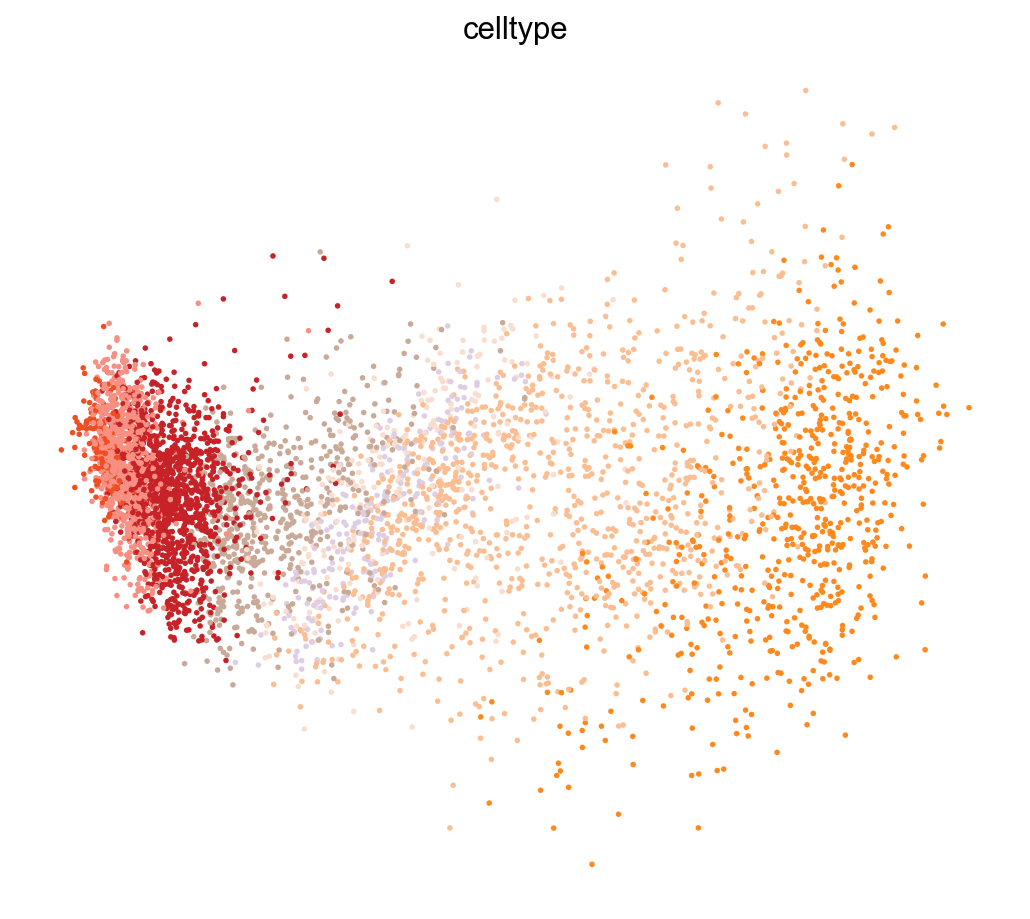

In [83]:
sc.pl.pca(adata, components=[1,4], color=["celltype"], size=25, legend_loc=None)

In [84]:
sc.external.pp.harmony_integrate(adata, key = "sample", basis='X_pca', adjusted_basis='X_pca_harmony')

2022-02-11 08:21:37,492 - harmonypy - INFO - Iteration 1 of 10
2022-02-11 08:21:38,232 - harmonypy - INFO - Iteration 2 of 10
2022-02-11 08:21:38,940 - harmonypy - INFO - Iteration 3 of 10
2022-02-11 08:21:39,773 - harmonypy - INFO - Iteration 4 of 10
2022-02-11 08:21:40,637 - harmonypy - INFO - Iteration 5 of 10
2022-02-11 08:21:41,487 - harmonypy - INFO - Iteration 6 of 10
2022-02-11 08:21:42,312 - harmonypy - INFO - Iteration 7 of 10
2022-02-11 08:21:42,842 - harmonypy - INFO - Iteration 8 of 10
2022-02-11 08:21:43,674 - harmonypy - INFO - Iteration 9 of 10
2022-02-11 08:21:44,597 - harmonypy - INFO - Iteration 10 of 10
2022-02-11 08:21:45,496 - harmonypy - INFO - Stopped before convergence


## k-NN graph

Build kNN graph

In [88]:
sc.pp.neighbors(adata, n_neighbors=25, use_rep='X_pca')

## UMAP

Run UMAP

In [53]:
# sc.tl.umap(adata, min_dist=0.5, n_components=2)

Plot UMAP

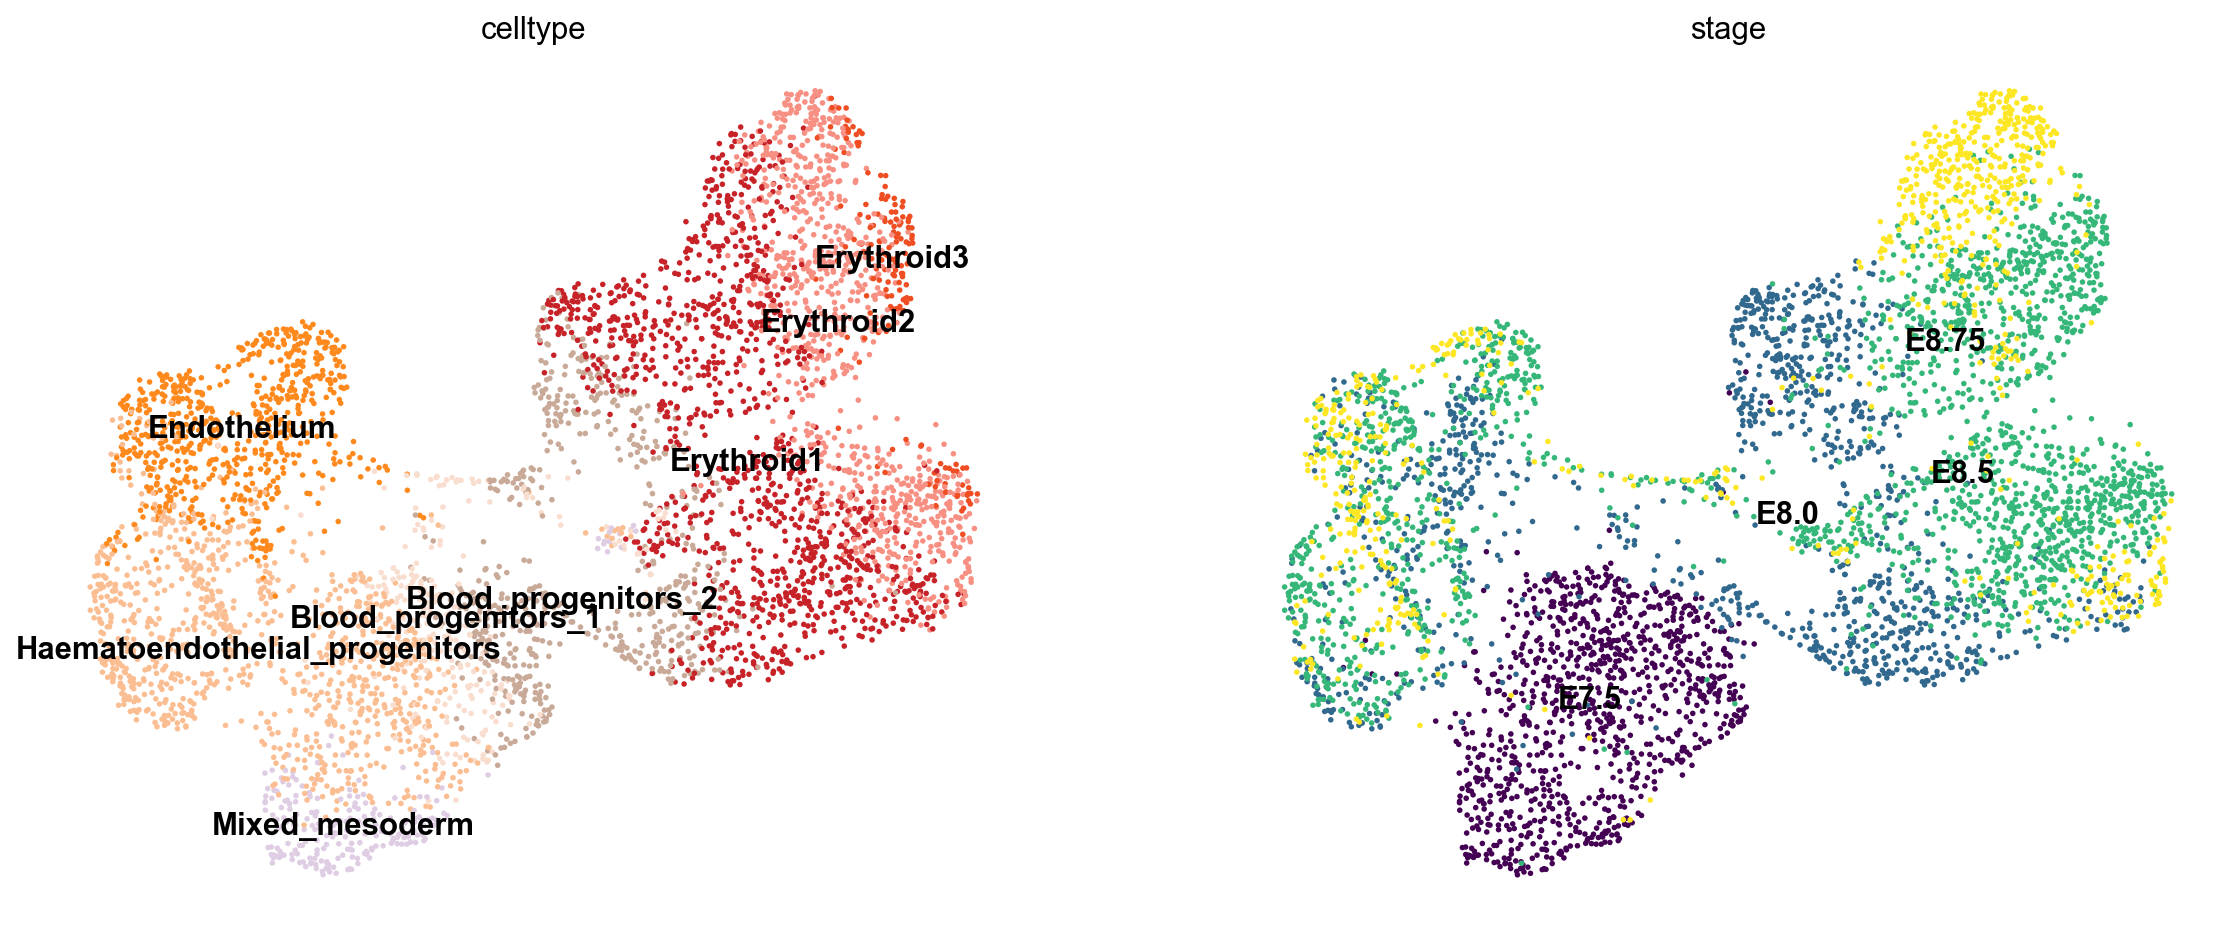

In [55]:
# sc.pl.umap(adata, color=["celltype","stage"], size=25, legend_loc="on data")

## Force-directed layout

In [91]:
sc.tl.draw_graph(adata, layout="fa", init_po`s=None)

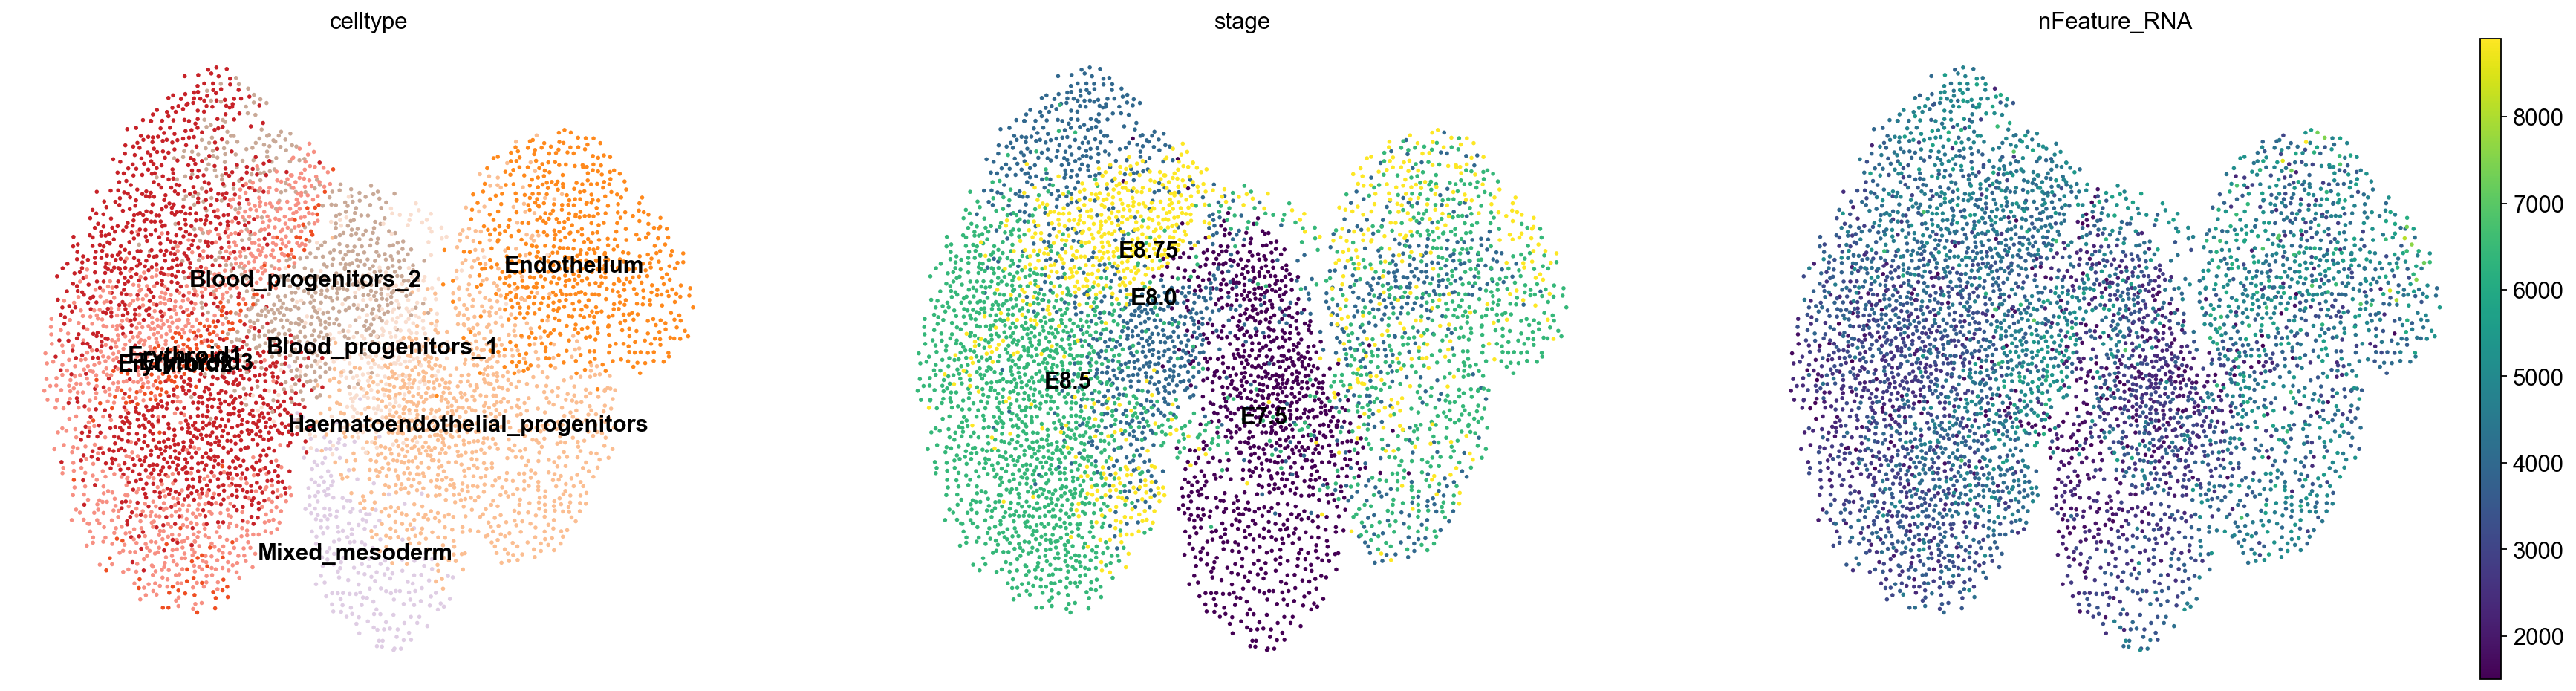

In [92]:
sc.pl.draw_graph(adata, color=["celltype","stage","nFeature_RNA"], size=25, legend_loc="on data")

# sc.pl.draw_graph(adata, color='celltype', size=12, legend_loc='on data', legend_fontsize=7,save = "blood_fa2_celltype.pdf")

In [71]:
adata.obs.columns

Index(['sample', 'stage', 'nFeature_RNA', 'mitochondrial_percent_RNA',
       'ribosomal_percent_RNA', 'celltype'],
      dtype='object')

In [65]:
# sc.external.pp.harmony_integrate(adata, key = "sample", basis='X_draw_graph_fa', adjusted_basis='X_draw_graph_fa_harmony')

2022-02-10 21:25:52,205 - harmonypy - INFO - Iteration 1 of 10
2022-02-10 21:25:52,897 - harmonypy - INFO - Iteration 2 of 10
2022-02-10 21:25:53,672 - harmonypy - INFO - Converged after 2 iterations


In [66]:
# sc.pl.draw_graph(adata, color=["celltype","stage","sample"], layout="X_draw_graph_fa_harmony", size=25, legend_loc="on data")

ValueError: Did not find draw_graph_X_draw_graph_fa_harmony in adata.obs. Did you compute layout X_draw_graph_fa_harmony?